# Network Generator
This is a notebook to help creating new networks by visualizing them. Use the `run all` button

In [1]:
# %pip install -e /Users/synneandreassen/Documents/MasterMaskinlæringCode/INF399/Environments/cyberwheel¨

In [2]:
import os
os.chdir('/Users/synneandreassen/Documents/MasterMaskinlæringCode/INF399/Environments/cyberwheel')
from cyberwheel.network.network_generation.test_random_network_generator import RandomNetworkGenerator
from cyberwheel.network.network_base import Network
print(os.getcwd())

/Users/synneandreassen/Documents/MasterMaskinlæringCode/INF399/Environments/cyberwheel


In [3]:
network = RandomNetworkGenerator()

## Add Hosts to Subnets

First, specify some host types to randomly pick from. Seed the RNG to get the same network each time.

In [4]:
server_types = ["mail_server", "file_server", "web_server", "ssh_jump_server", "proxy_server"]
all_types = ["mail_server", "file_server", "web_server", "ssh_jump_server", "proxy_server", "workstation"]
network_name = "random_network"
generated_network = network.generate_and_save(host_types=all_types, network_name=network_name)

Initialized NetworkYAMLGenerator with filename 'random_network'
Generated random network 'random_network' with 7 subnets and 45 hosts.


## Visualize the New Network

**Hosts**

* Blue node: decoy
* Green node: workstation
* Red node: server
* Black node: other

**Subnets**

* Cyan node: subnet

**Router**

* Orange node: router
* Black node: other


Router(name="core_router", default_route="None", routes="set()"
Subnet(name="subnet_0", ip_network="192.168.0.0/24", router="core_router"
Subnet(name="subnet_1", ip_network="192.168.1.0/24", router="core_router"
Subnet(name="subnet_2", ip_network="192.168.2.0/24", router="core_router"
Subnet(name="subnet_3", ip_network="192.168.3.0/24", router="core_router"
Subnet(name="subnet_4", ip_network="192.168.4.0/24", router="core_router"
Subnet(name="subnet_5", ip_network="192.168.5.0/24", router="core_router"
Subnet(name="subnet_6", ip_network="192.168.6.0/24", router="core_router"
Host(name="host_000", subnet="subnet_0",  host_type="name='web_server' type=<HostTypes.SERVER: 2> services={Service(name='WindowsPrivilegeEscalationExploitableService', port=8040, protocol='tcp', version='1', vulns={'CVE-2023-21512', 'CVE-2020-25168', 'CVE-2022-32219', 'CVE-2023-4816', 'CVE-2023-33972', 'CVE-2023-1584', 'CVE-2021-27772', 'CVE-2023-29463', 'CVE-2021-43786', 'CVE-2022-21712'}, description='exploitabl

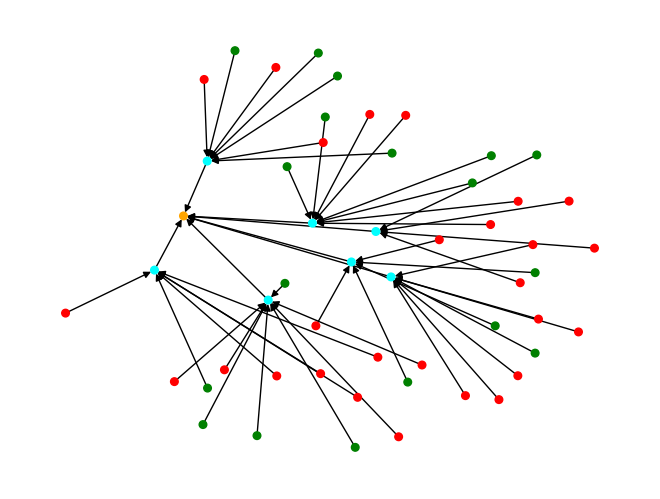

In [5]:
cyberwheel_network=Network.create_network_from_yaml((f"cyberwheel/data/configs/network/{network_name}.yaml"))
labels = {}
for node, data in cyberwheel_network.graph.nodes(data=True):
    if not hasattr(data['data'], 'host_type') or data['data'].host_type is None:
        labels[node] = data['data'].name
    else:
        labels[node] = f"{data['data'].name}, {data['data'].host_type.name}"

cyberwheel_network.draw(filename="")